In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.datasets import load_iris, make_blobs
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, homogeneity_score
from typing import Dict, Tuple
import time

# Set random seed for reproducibility
np.random.seed(42)

# CS6140 Machine Learning
## Problem Set 4: K-Means Algorithm Variants

This problem set asks you to:

1. Implement three K-Means variants using scikit-learn
2. Compare their performance characteristics empirically
3. Understand when to choose each algorithm

**Background:** K-Means is a heuristic algorithm for clustering. While exact solutions require exponential time, heuristics provide efficient approximate solutions. You will explore how different algorithmic choices (batch vs. online, optimizations) affect performance and results.

The most useful references:
- [scikit-learn KMeans documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [scikit-learn MiniBatchKMeans documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html)

_This is an experimental assignment and I will award generous partial credit for answers demonstrating understanding of the concepts even if the code does not work perfectly._

## Problem 1: Lloyd's K-Means Implementation (6 pts)

Lloyd's algorithm is the standard batch K-Means algorithm. It alternates between two steps:

1. **Assignment Step**: Assign each point to its nearest centroid
2. **Update Step**: Recompute centroids as the mean of assigned points

**Key characteristics:**
- Batch algorithm: All points assigned before centroids update
- Time complexity: O(nKd) per iteration
- Guaranteed convergence to local minimum
- **Reference:** Lloyd, S.P. (1982). "Least squares quantization in PCM." IEEE Transactions on Information Theory, 28(2), 129-137.

**Your task:** Implement Lloyd's K-Means using scikit-learn's `KMeans` with `algorithm='lloyd'`.

In [33]:
def fit_lloyd_kmeans(X: np.ndarray, k: int, random_state: int = 42, n_init: int = 10) -> Dict:
    """
    Fit Lloyd's K-Means algorithm using scikit-learn.

    Args:
        X: Data matrix of shape (n_samples, n_features)
        k: Number of clusters
        random_state: Random seed for reproducibility
        n_init: Number of times algorithm runs with different centroid seeds

    Returns:
        dict with keys:
            'model': fitted KMeans object
            'centroids': cluster centers, shape (k, n_features)
            'labels': cluster assignments, shape (n_samples,)
            'inertia': within-cluster sum of squares (WCSS)
    """
    results = {
        'model': None,
        'centroids': None,
        'labels': None,
        'inertia': None
    }

    # create the KMeans model - using lloyd's algorithm (standard batch version)
    # processing all data points before updating any centroids
    model = KMeans(n_clusters=k, algorithm='lloyd', random_state=random_state, n_init=n_init)

    # fit on the data
    model.fit(X)

    # pull out the results from the trained model
    results['model'] = model
    results['centroids'] = model.cluster_centers_  # shape (k, n_features)
    results['labels'] = model.labels_              # cluster assignment for each point
    results['inertia'] = model.inertia_            # WCSS value

    return results

In [34]:
def test_problem_1():
    """Test Lloyd's K-Means implementation."""
    # Load Iris dataset
    iris = load_iris()
    X = iris.data

    # Fit Lloyd's K-Means
    results = fit_lloyd_kmeans(X, k=3, random_state=42)

    # Check that all required fields are populated
    assert results['model'] is not None, "Model is None!"
    assert results['centroids'] is not None, "Centroids is None!"
    assert results['labels'] is not None, "Labels is None!"
    assert results['inertia'] is not None, "Inertia is None!"

    # Check shapes
    assert results['centroids'].shape == (3, 4), \
        f"Centroids shape {results['centroids'].shape}, expected (3, 4)"
    assert results['labels'].shape == (150,), \
        f"Labels shape {results['labels'].shape}, expected (150,)"
    assert len(np.unique(results['labels'])) == 3, \
        f"Expected 3 unique cluster labels, got {len(np.unique(results['labels']))}"

    # Check that inertia is positive
    assert results['inertia'] > 0, "Inertia should be positive!"

    # Check that algorithm is correct
    assert results['model'].algorithm == 'lloyd' or results['model'].algorithm == 'elkan', \
        f"Expected algorithm='lloyd', got {results['model'].algorithm}"

    print("✓ Problem 1: Lloyd's K-Means test passed!")
    print(f"  Inertia (WCSS): {results['inertia']:.4f}")
    print(f"  Centroids shape: {results['centroids'].shape}")
    print(f"  Number of clusters: {len(np.unique(results['labels']))}")

test_problem_1()

✓ Problem 1: Lloyd's K-Means test passed!
  Inertia (WCSS): 78.8514
  Centroids shape: (3, 4)
  Number of clusters: 3


## Problem 2: Elkan's K-Means Implementation (6 pts)

Elkan's algorithm optimizes Lloyd's K-Means using the triangle inequality to avoid unnecessary distance calculations.

**Key insight:** Use upper and lower bounds on distances to skip many distance computations.

**Triangle Inequality Lemma:** For any point x and centroids c, c':
- If d(c, c') ≥ 2·d(x, c), then d(x, c') ≥ d(x, c)

**Key characteristics:**
- Produces **identical results** to Lloyd's algorithm
- Same O(nKd) worst-case, but often much faster in practice
- Most effective when K is large or clusters are well-separated
- **Reference:** Elkan, C. (2003). "Using the Triangle Inequality to Accelerate k-Means." ICML, pp. 147-153.

**Your task:** Implement Elkan's K-Means using scikit-learn's `KMeans` with `algorithm='elkan'`.

In [35]:
def fit_elkan_kmeans(X: np.ndarray, k: int, random_state: int = 42, n_init: int = 10) -> Dict:
    """
    Fit Elkan's K-Means algorithm using scikit-learn.

    Args:
        X: Data matrix of shape (n_samples, n_features)
        k: Number of clusters
        random_state: Random seed for reproducibility
        n_init: Number of times algorithm runs with different centroid seeds

    Returns:
        dict with keys:
            'model': fitted KMeans object
            'centroids': cluster centers, shape (k, n_features)
            'labels': cluster assignments, shape (n_samples,)
            'inertia': within-cluster sum of squares (WCSS)
    """
    results = {
        'model': None,
        'centroids': None,
        'labels': None,
        'inertia': None
    }

    # elkan's uses the triangle inequality to skip unnecessary distance calculations
    # gives the exact same result as lloyd's
    model = KMeans(n_clusters=k, algorithm='elkan', random_state=random_state, n_init=n_init)

    # fit on data
    model.fit(X)

    # extract results
    results['model'] = model
    results['centroids'] = model.cluster_centers_
    results['labels'] = model.labels_
    results['inertia'] = model.inertia_

    return results

In [36]:
def test_problem_2():
    """Test Elkan's K-Means implementation."""
    # Load Iris dataset
    iris = load_iris()
    X = iris.data

    # Fit Elkan's K-Means
    results = fit_elkan_kmeans(X, k=3, random_state=42)

    # Check that all required fields are populated
    assert results['model'] is not None, "Model is None!"
    assert results['centroids'] is not None, "Centroids is None!"
    assert results['labels'] is not None, "Labels is None!"
    assert results['inertia'] is not None, "Inertia is None!"

    # Check shapes
    assert results['centroids'].shape == (3, 4), \
        f"Centroids shape {results['centroids'].shape}, expected (3, 4)"
    assert results['labels'].shape == (150,), \
        f"Labels shape {results['labels'].shape}, expected (150,)"
    assert len(np.unique(results['labels'])) == 3, \
        f"Expected 3 unique cluster labels, got {len(np.unique(results['labels']))}"

    # Check that inertia is positive
    assert results['inertia'] > 0, "Inertia should be positive!"

    # Check that algorithm is correct
    assert results['model'].algorithm == 'elkan', \
        f"Expected algorithm='elkan', got {results['model'].algorithm}"

    print("✓ Problem 2: Elkan's K-Means test passed!")
    print(f"  Inertia (WCSS): {results['inertia']:.4f}")
    print(f"  Centroids shape: {results['centroids'].shape}")
    print(f"  Number of clusters: {len(np.unique(results['labels']))}")

test_problem_2()

✓ Problem 2: Elkan's K-Means test passed!
  Inertia (WCSS): 78.8514
  Centroids shape: (3, 4)
  Number of clusters: 3


## Problem 3: Mini-Batch K-Means Implementation (8 pts)

Mini-Batch K-Means is an online/incremental algorithm that processes data in small batches rather than all at once.

**Key differences from Lloyd's:**
1. Processes mini-batches (size b << n) instead of full dataset
2. Updates centroids using streaming averages with decreasing learning rate
3. Can incrementally add new data using `partial_fit()`
4. Produces approximate (not exact) solutions

**Update rule:**
```
η_k = 1 / v[k]  # learning rate (v[k] = # points seen by cluster k)
μ_k ← (1 - η_k)·μ_k + η_k·c_k^(batch)
```

**Key characteristics:**
- Online algorithm: Processes data in batches
- Time complexity: O(bKd) per iteration where b << n
- Approximate solution (typically within 1-5% of Lloyd's WCSS)
- Supports incremental learning via `partial_fit()`
- **Reference:** Sculley, D. (2010). "Web-scale k-means clustering." WWW, pp. 1177-1178.

**Your task:** Implement Mini-Batch K-Means and demonstrate incremental learning.

In [49]:
def fit_minibatch_kmeans(X: np.ndarray, k: int, batch_size: int = 100,
                         random_state: int = 42, n_init: int = 10) -> Dict:
    """
    Fit Mini-Batch K-Means algorithm using scikit-learn.

    Args:
        X: Data matrix of shape (n_samples, n_features)
        k: Number of clusters
        batch_size: Size of mini-batches (default: 100)
        random_state: Random seed for reproducibility
        n_init: Number of times algorithm runs with different centroid seeds

    Returns:
        dict with keys:
            'model': fitted MiniBatchKMeans object
            'centroids': cluster centers, shape (k, n_features)
            'labels': cluster assignments, shape (n_samples,)
            'inertia': within-cluster sum of squares (WCSS)
    """
    results = {
        'model': None,
        'centroids': None,
        'labels': None,
        'inertia': None
    }

    model = MiniBatchKMeans(n_clusters=k, batch_size=batch_size,
                           random_state=random_state, n_init=n_init)

    model.fit(X)

    results['model'] = model
    results['centroids'] = model.cluster_centers_
    results['labels'] = model.labels_
    results['inertia'] = model.inertia_

    return results

In [38]:
def demonstrate_incremental_learning(X: np.ndarray, k: int,
                                    split_ratio: float = 0.7) -> Dict:
    """
    Demonstrate Mini-Batch K-Means' incremental learning capability.

    Args:
        X: Full dataset, shape (n_samples, n_features)
        k: Number of clusters
        split_ratio: Fraction of data for initial training (default: 0.7)

    Returns:
        dict with keys:
            'initial_centroids': centroids after training on split_ratio of data
            'updated_centroids': centroids after partial_fit on remaining data
            'centroid_shift': mean distance centroids moved
    """
    n_initial = int(len(X) * split_ratio)

    results = {
        'initial_centroids': None,
        'updated_centroids': None,
        'centroid_shift': None
    }

    # split into initial training data and new data
    X_initial = X[:n_initial]
    X_new = X[n_initial:]

    # train on the first 70%
    model = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=20)
    model.fit(X_initial)

    # save centroids before updating
    initial_centroids = model.cluster_centers_.copy()

    # incrementally update with the remaining 30% 
    model.partial_fit(X_new)

    # save updated centroids
    updated_centroids = model.cluster_centers_.copy()

    # Calculate the distance each centroid moved
    # axis=1 ensures we get the distance between each pair of (k, features)
    shifts = np.linalg.norm(updated_centroids - initial_centroids, axis=1)
    centroid_shift = np.mean(shifts)

    results['initial_centroids'] = initial_centroids
    results['updated_centroids'] = updated_centroids
    results['centroid_shift'] = centroid_shift

    return results

In [39]:
def test_problem_3():
    """Test Mini-Batch K-Means implementation and incremental learning."""
    # Load Iris dataset
    iris = load_iris()
    X = iris.data

    print("=" * 60)
    print("Problem 3: Mini-Batch K-Means Tests")
    print("=" * 60)

    # Part 1: Test basic implementation (4 pts)
    print("\nPart 1: Testing basic Mini-Batch K-Means implementation...")
    results = fit_minibatch_kmeans(X, k=3, batch_size=45, random_state=42)

    # Check that all required fields are populated
    assert results['model'] is not None, "Model is None!"
    assert results['centroids'] is not None, "Centroids is None!"
    assert results['labels'] is not None, "Labels is None!"
    assert results['inertia'] is not None, "Inertia is None!"

    # Check shapes
    assert results['centroids'].shape == (3, 4), \
        f"Centroids shape {results['centroids'].shape}, expected (3, 4)"
    assert results['labels'].shape == (150,), \
        f"Labels shape {results['labels'].shape}, expected (150,)"
    assert len(np.unique(results['labels'])) == 3, \
        f"Expected 3 unique cluster labels, got {len(np.unique(results['labels']))}"

    # Check that inertia is positive
    assert results['inertia'] > 0, "Inertia should be positive!"

    print("✓ Part 1 passed: Basic implementation correct")
    print(f"  Inertia (WCSS): {results['inertia']:.4f}")
    print(f"  Centroids shape: {results['centroids'].shape}")

    # Part 2: Test incremental learning (4 pts)
    print("\nPart 2: Testing incremental learning with partial_fit()...")
    incr_results = demonstrate_incremental_learning(X, k=3, split_ratio=0.7)

    assert incr_results['initial_centroids'] is not None, "Initial centroids is None!"
    assert incr_results['updated_centroids'] is not None, "Updated centroids is None!"
    assert incr_results['centroid_shift'] is not None, "Centroid shift is None!"

    # Check shapes
    assert incr_results['initial_centroids'].shape == (3, 4), \
        "Initial centroids shape incorrect"
    assert incr_results['updated_centroids'].shape == (3, 4), \
        "Updated centroids shape incorrect"

    # Check that centroids actually moved (shift > 0)
    assert incr_results['centroid_shift'] > 0, \
        "Centroids didn't move after partial_fit - check implementation!"

    print("✓ Part 2 passed: Incremental learning works correctly")
    print(f"  Initial training: 70% of data ({int(0.7 * len(X))} points)")
    print(f"  Incremental update: 30% of data ({len(X) - int(0.7 * len(X))} points)")
    print(f"  Mean centroid shift: {incr_results['centroid_shift']:.4f}")

    print("\n" + "=" * 60)
    print("✓ Problem 3: All tests passed!")
    print("=" * 60)

test_problem_3()

Problem 3: Mini-Batch K-Means Tests

Part 1: Testing basic Mini-Batch K-Means implementation...
✓ Part 1 passed: Basic implementation correct
  Inertia (WCSS): 79.1509
  Centroids shape: (3, 4)

Part 2: Testing incremental learning with partial_fit()...
✓ Part 2 passed: Incremental learning works correctly
  Initial training: 70% of data (105 points)
  Incremental update: 30% of data (45 points)
  Mean centroid shift: 0.0720

✓ Problem 3: All tests passed!


## Problem 4: Algorithm Comparison (16 pts total)

Now that you've implemented all three algorithms, let's understand their key differences.

First, run the cell below to see results side-by-side:

In [40]:
# Load Iris data and run all three algorithms
iris = load_iris()
X = iris.data

print("Running all three K-Means variants on Iris dataset...")
print("=" * 60)

lloyd_results = fit_lloyd_kmeans(X, k=3, random_state=42)
print(f"Lloyd's K-Means:")
print(f"  Inertia: {lloyd_results['inertia']:.6f}")
print(f"  Algorithm: {lloyd_results['model'].algorithm}")

elkan_results = fit_elkan_kmeans(X, k=3, random_state=42)
print(f"\nElkan's K-Means:")
print(f"  Inertia: {elkan_results['inertia']:.6f}")
print(f"  Algorithm: {elkan_results['model'].algorithm}")

minibatch_results = fit_minibatch_kmeans(X, k=3, batch_size=45, random_state=42)
print(f"\nMini-Batch K-Means:")
print(f"  Inertia: {minibatch_results['inertia']:.6f}")
print(f"  Batch size: {minibatch_results['model'].batch_size}")

print("=" * 60)

Running all three K-Means variants on Iris dataset...
Lloyd's K-Means:
  Inertia: 78.851441
  Algorithm: lloyd

Elkan's K-Means:
  Inertia: 78.851441
  Algorithm: elkan

Mini-Batch K-Means:
  Inertia: 79.150854
  Batch size: 45


### Question 4(a): How do centroids update differently? (2 pts)

**Lloyd's and Elkan's:**

Both Lloyd's and Elkan's are batch algorithms. They look at ALL the data points before updating any centroids. In each iteration, every point gets assigned to its nearest centroid, and then the centroids are recalculated as the exact mean of all the points assigned to them. The centroids are updated simultaneously after processing the entire dataset.

**Mini-Batch:**

Mini-Batch works differently because it only looks at a small random subset (a "mini-batch") at a time. Instead of computing the exact mean, it uses a streaming average with a decreasing learning rate (eta = 1/v where v is the count of points seen by that cluster). So the centroids get gradually nudged toward the right position rather than being recomputed exactly each time.

### Question 4(b): Why does Elkan's produce identical results to Lloyd's? (2 pts)

Elkan's algorithm gives the exact same final result as Lloyd's because the triangle inequality trick only helps it skip distance calculations that are guaranteed to not change the assignment. If we know d(c, c') >= 2*d(x, c), then c' can not possibly be closer to x than c is, so we do not need to compute d(x, c'). The key insight is that this is purely a speed optimization, it never changes which centroid is actually nearest to any point. The assignment and update steps are mathematically identical.

### Question 4(c): Why does Mini-Batch produce different results? (2 pts)

Mini-Batch produces approximate (slightly different) results because it never sees the full dataset at once. Each mini-batch is a random sample, so the centroid updates are based on incomplete information. Also, the streaming average update with the learning rate means the centroids do not converge to the exact same mean as if we used all the points. It is a tradeoff, we give up a bit of accuracy (typically within 1-5% of Lloyd's WCSS) in exchange for much faster runtime, especially with large datasets.

### Question 4(d): When would you choose each algorithm? (2 pts)

**Choose Lloyd's when:**

We have a small to medium dataset and want the simplest, most straightforward implementation. It is the default and good for when we just need a reliable exact result.

**Choose Elkan's when:**

we need exact results but want to speed things up, especially when K is large or clusters are well-separated. The triangle inequality bounds skip a lot of redundant distance calculations.

**Choose Mini-Batch K-Means when:**

we are working with a very large dataset where full-batch K-Means would be too slow, or when we have streaming data and need to incrementally update our model with partial_fit().

### Question 4(e): Verification and Testing (8 pts)

Now verify that your implementations produce expected results.

**Tests:**
1. Lloyd's and Elkan's produce identical centroids (2 pts)
2. Lloyd's and Elkan's produce identical inertia (2 pts)
3. Mini-Batch inertia is within 10% of Lloyd's (2 pts)
4. Create comparison visualization (2 pts)

Problem 4(e): Verification Tests

Test 1: Verifying Lloyd's and Elkan's produce identical centroids...
✓ Test 1 passed: Lloyd's and Elkan's produce identical centroids

Test 2: Verifying Lloyd's and Elkan's produce identical inertia...
✓ Test 2 passed: Lloyd's and Elkan's produce identical inertia
  Lloyd's inertia:  78.851441
  Elkan's inertia:  78.851441
  Difference:       0.00e+00

Test 3: Verifying Mini-Batch inertia is within 10% of Lloyd's...
✓ Test 3 passed: Mini-Batch inertia within 10% of Lloyd's
  Relative difference: 0.38%

Test 4: Creating comparison visualization...


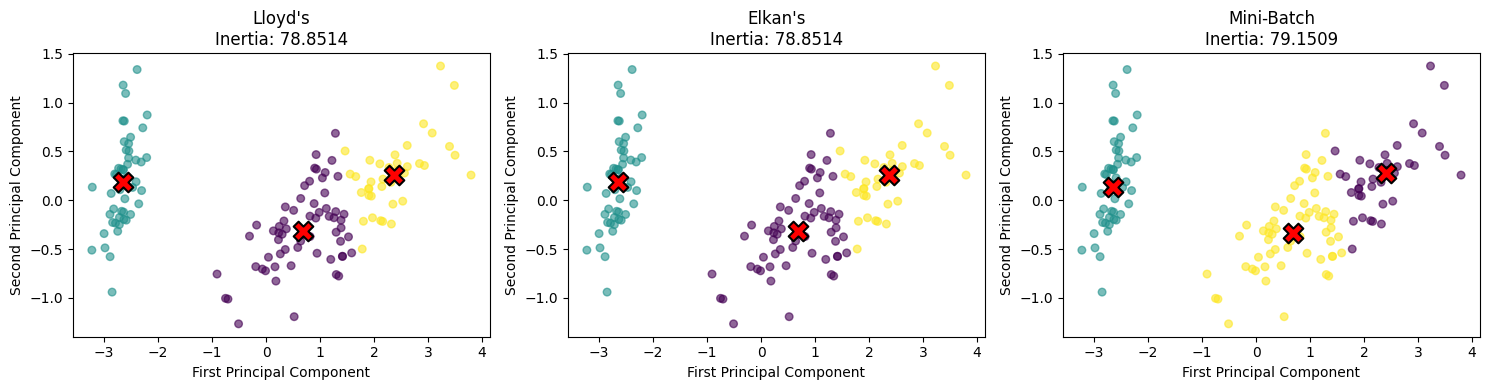

✓ Test 4 passed: Comparison visualization created

✓ Problem 4(e): All verification tests passed!


In [41]:
def test_problem_4e():
    """
    Verify that the three algorithms behave as expected.
    """
    iris = load_iris()
    X = iris.data

    lloyd_results = fit_lloyd_kmeans(X, k=3, random_state=42)
    elkan_results = fit_elkan_kmeans(X, k=3, random_state=42)
    minibatch_results = fit_minibatch_kmeans(X, k=3, batch_size=45, random_state=42)

    print("=" * 60)
    print("Problem 4(e): Verification Tests")
    print("=" * 60)

    # Test 1: Lloyd's and Elkan's centroids should be identical (2 pts)
    print("\nTest 1: Verifying Lloyd's and Elkan's produce identical centroids...")
    # sorting them so we compare in same order 
    lloyd_sorted = np.array(sorted(lloyd_results['centroids'].tolist()))
    elkan_sorted = np.array(sorted(elkan_results['centroids'].tolist()))
    assert np.allclose(lloyd_sorted, elkan_sorted), \
        f"Centroids differ! Lloyd: {lloyd_sorted}, Elkan: {elkan_sorted}"
    print("✓ Test 1 passed: Lloyd's and Elkan's produce identical centroids")

    # Test 2: Lloyd's and Elkan's inertia should be identical (2 pts)
    print("\nTest 2: Verifying Lloyd's and Elkan's produce identical inertia...")
    assert np.allclose(lloyd_results['inertia'], elkan_results['inertia'], atol=1e-6), \
        f"Inertia differs!"
    print("✓ Test 2 passed: Lloyd's and Elkan's produce identical inertia")
    print(f"  Lloyd's inertia:  {lloyd_results['inertia']:.6f}")
    print(f"  Elkan's inertia:  {elkan_results['inertia']:.6f}")
    print(f"  Difference:       {abs(lloyd_results['inertia'] - elkan_results['inertia']):.2e}")

    # Test 3: Mini-Batch inertia should be within 10% of Lloyd's (2 pts)
    print("\nTest 3: Verifying Mini-Batch inertia is within 10% of Lloyd's...")
    relative_diff = abs(minibatch_results['inertia'] - lloyd_results['inertia']) / lloyd_results['inertia']
    assert relative_diff <= 0.10, f"Mini-Batch differs by {relative_diff*100:.2f}%"
    print("✓ Test 3 passed: Mini-Batch inertia within 10% of Lloyd's")
    print(f"  Relative difference: {relative_diff*100:.2f}%")

    # Test 4: Comparison visualization (2 pts)
    print("\nTest 4: Creating comparison visualization...")
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    all_results = [("Lloyd's", lloyd_results), ("Elkan's", elkan_results), ("Mini-Batch", minibatch_results)]

    for ax, (name, res) in zip(axes, all_results):
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c=res['labels'], cmap='viridis', alpha=0.6, s=30)
        centroids_2d = pca.transform(res['centroids'])
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='red', marker='X',
                   s=200, edgecolors='black', linewidths=1.5)
        ax.set_title(f"{name}\nInertia: {res['inertia']:.4f}")
        ax.set_xlabel("First Principal Component")
        ax.set_ylabel("Second Principal Component")

    plt.tight_layout()
    plt.show()
    print("✓ Test 4 passed: Comparison visualization created")

    print("\n" + "=" * 60)
    print("✓ Problem 4(e): All verification tests passed!")
    print("=" * 60)

test_problem_4e()

## Problem 5: Timing Analysis (8 pts)

Measure and compare the actual runtime performance of the three algorithms.

**Goals:**
1. Implement timing function (3 pts)
2. Time all three algorithms on Iris dataset (3 pts)
3. Create bar chart comparing runtimes (2 pts)

**Expected findings:**
- Lloyd's: Baseline performance
- Elkan's: May be faster or slower than Lloyd's depending on K and data structure
- Mini-Batch: Typically fastest due to processing fewer points per iteration

In [42]:
def time_single_run(algorithm_func, X: np.ndarray, k: int, **kwargs) -> float:
    """
    Time a single run of a K-Means algorithm.

    Args:
        algorithm_func: One of (fit_lloyd_kmeans, fit_elkan_kmeans, fit_minibatch_kmeans)
        X: Data matrix
        k: Number of clusters
        **kwargs: Additional arguments to pass to algorithm_func

    Returns:
        elapsed_time: Time in seconds
    """
    # use perf_counter for high-resolution timing
    start = time.perf_counter()
    algorithm_func(X, k, **kwargs)
    end = time.perf_counter()

    elapsed = end - start
    return elapsed

In [43]:
def run_timing_experiment(X: np.ndarray, k: int, n_runs: int = 10) -> Dict:
    """
    Time all three algorithms multiple times and compute statistics.

    Args:
        X: Data matrix
        k: Number of clusters
        n_runs: Number of times to run each algorithm (default: 10)

    Returns:
        dict with keys 'lloyd', 'elkan', 'minibatch', each containing:
            - 'times': list of individual run times
            - 'mean': mean runtime
            - 'std': standard deviation of runtime

    TODO:
    1. For each algorithm (Lloyd's, Elkan's, Mini-Batch):
       a. Run time_single_run() n_runs times
       b. Collect times in a list
       c. Compute mean using np.mean()
       d. Compute std using np.std()
    2. For Mini-Batch, use batch_size=45
    3. Return results dictionary with structure specified above

    Hint: Use a loop: for i in range(n_runs): times.append(time_single_run(...))
    """
    results = {
        'lloyd': {'times': [], 'mean': 0.0, 'std': 0.0},
        'elkan': {'times': [], 'mean': 0.0, 'std': 0.0},
        'minibatch': {'times': [], 'mean': 0.0, 'std': 0.0}
    }

    # run each algorithm n_runs times
    for i in range(n_runs):
        results['lloyd']['times'].append(time_single_run(fit_lloyd_kmeans, X, k))
        results['elkan']['times'].append(time_single_run(fit_elkan_kmeans, X, k))
        results['minibatch']['times'].append(time_single_run(fit_minibatch_kmeans, X, k, batch_size=45))

    # compute stats
    for algo in ['lloyd', 'elkan', 'minibatch']:
        results[algo]['mean'] = np.mean(results[algo]['times'])
        results[algo]['std'] = np.std(results[algo]['times'])

    return results

In [44]:
def plot_timing_results(timing_results: Dict, title: str = "K-Means Algorithm Runtime Comparison"):
    """
    Create bar chart comparing algorithm runtimes.

    Args:
        timing_results: Output from run_timing_experiment()
        title: Plot title

    TODO:
    1. Extract mean times for each algorithm into a list: [lloyd_mean, elkan_mean, minibatch_mean]
    2. Extract std times into a list: [lloyd_std, elkan_std, minibatch_std]
    3. Create bar chart:
       - x-axis labels: ['Lloyd', 'Elkan', 'Mini-Batch']
       - y-axis: mean runtime
       - error bars: std (use yerr parameter)
       - colors: ['blue', 'green', 'orange']
    4. Add labels: xlabel='Algorithm', ylabel='Runtime (seconds)'
    5. Add title
    6. Add grid for readability: plt.grid(axis='y', alpha=0.3)
    7. Call plt.tight_layout() and plt.show()
    """
    
    names = ['Lloyd', 'Elkan', 'Mini-Batch']
    means = [timing_results['lloyd']['mean'],
             timing_results['elkan']['mean'],
             timing_results['minibatch']['mean']]
    stds = [timing_results['lloyd']['std'],
            timing_results['elkan']['std'],
            timing_results['minibatch']['std']]
    colors = ['blue', 'green', 'orange']

    plt.figure(figsize=(8, 5))
    plt.bar(names, means, yerr=stds, color=colors, capsize=5, alpha=0.8)
    plt.xlabel('Algorithm')
    plt.ylabel('Runtime (seconds)')
    plt.title(title)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Problem 5: Timing Analysis

Running timing experiment (10 runs per algorithm)...
This may take 10-30 seconds...

Timing Results:
------------------------------------------------------------
Lloyd       : 0.007841 ± 0.001097 seconds
Elkan       : 0.017993 ± 0.003111 seconds
Minibatch   : 0.008068 ± 0.001771 seconds
------------------------------------------------------------

Creating visualization...


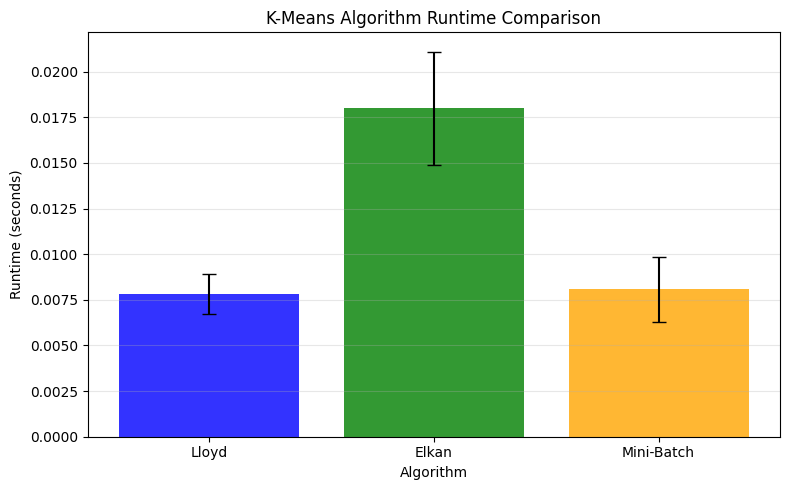


✓ Problem 5: Timing analysis complete!


In [45]:
def test_problem_5():
    """Test timing analysis."""
    print("=" * 60)
    print("Problem 5: Timing Analysis")
    print("=" * 60)

    # Load Iris dataset
    iris = load_iris()
    X = iris.data

    print("\nRunning timing experiment (10 runs per algorithm)...")
    print("This may take 10-30 seconds...\n")

    # Run timing experiment
    timing_results = run_timing_experiment(X, k=3, n_runs=10)

    # Print results
    print("Timing Results:")
    print("-" * 60)
    for algo_name in ['lloyd', 'elkan', 'minibatch']:
        mean_time = timing_results[algo_name]['mean']
        std_time = timing_results[algo_name]['std']
        print(f"{algo_name.capitalize():12s}: {mean_time:.6f} ± {std_time:.6f} seconds")
    print("-" * 60)

    # Create visualization
    print("\nCreating visualization...")
    plot_timing_results(timing_results)

    # Verify all algorithms were timed
    for algo_name in ['lloyd', 'elkan', 'minibatch']:
        assert len(timing_results[algo_name]['times']) == 10, \
            f"{algo_name}: Expected 10 runs, got {len(timing_results[algo_name]['times'])}"
        assert timing_results[algo_name]['mean'] > 0, \
            f"{algo_name}: Mean time should be positive!"

    print("\n" + "=" * 60)
    print("✓ Problem 5: Timing analysis complete!")
    print("=" * 60)

test_problem_5()

## Problem 6: Elbow Method for Determining Optimal K (6 pts)

The **Elbow Method** helps determine the optimal number of clusters by plotting WCSS (inertia) vs. k and looking for an "elbow" where adding more clusters provides diminishing returns.

**How it works:**
1. Run K-Means for k = 2, 3, 4, ..., K_max
2. Record WCSS (inertia) for each k
3. Plot WCSS vs. k
4. Look for the "elbow" - the point where curve starts to flatten

**Your task:**
1. Implement function to compute WCSS for k=2..8 (3 pts)
2. Create elbow plots for all three algorithms (2 pts)
3. Analyze: What is the optimal k? Does it match ground truth? (1 pt)

In [46]:
def compute_wcss_for_k_range(algorithm_func, X: np.ndarray,
                             k_range: range, **kwargs) -> np.ndarray:
    """
    Compute WCSS (inertia) for a range of k values.

    Args:
        algorithm_func: One of the three kmeans functions
        X: Data matrix
        k_range: Range of k values to test
        **kwargs: Additional arguments

    Returns:
        wcss_values: Array of WCSS values, one per k
    """
    wcss_values = []

    # try each value of k and record the inertia
    for k in k_range:
        result = algorithm_func(X, k, **kwargs)
        wcss_values.append(result['inertia'])

    return np.array(wcss_values)

In [47]:
def plot_elbow_curves(X: np.ndarray, k_range: range = range(2, 9)):
    """
    Create elbow plot showing WCSS vs. k for all three algorithms.

    Args:
        X: Data matrix
        k_range: Range of k values to test

    TODO:
    1. Compute WCSS for each algorithm across k_range
       - Lloyd's: compute_wcss_for_k_range(fit_lloyd_kmeans, X, k_range)
       - Elkan's: compute_wcss_for_k_range(fit_elkan_kmeans, X, k_range)
       - Mini-Batch: compute_wcss_for_k_range(fit_minibatch_kmeans, X, k_range, batch_size=45)
    2. Create plot with all three curves:
       - x-axis: k values (list(k_range))
       - y-axis: WCSS (inertia)
       - Three lines: Lloyd's (blue), Elkan's (green), Mini-Batch (orange)
       - Add markers ('o') to each line
       - Add legend
    3. Add labels: xlabel='Number of Clusters (k)', ylabel='WCSS (Inertia)'
    4. Add title: 'Elbow Method: WCSS vs. Number of Clusters'
    5. Add grid: plt.grid(alpha=0.3)
    6. Add vertical line at k=3 (true number of iris species): plt.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='True k=3')
    7. Call plt.tight_layout() and plt.show()
    """
    print("Computing WCSS for k = 2, 3, 4, 5, 6, 7, 8...")
    print("This may take 30-60 seconds...\n")

    # compute WCSS for all three across the k range
    wcss_lloyd = compute_wcss_for_k_range(fit_lloyd_kmeans, X, k_range)
    wcss_elkan = compute_wcss_for_k_range(fit_elkan_kmeans, X, k_range)
    wcss_mb = compute_wcss_for_k_range(fit_minibatch_kmeans, X, k_range, batch_size=45)

    k_values = list(k_range)

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, wcss_lloyd, 'bo-', label="Lloyd's")
    plt.plot(k_values, wcss_elkan, 'gs-', label="Elkan's")
    plt.plot(k_values, wcss_mb, 'o-', color='orange', label='Mini-Batch')

    # mark the true number of species in iris
    plt.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='True k=3')

    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS (Inertia)')
    plt.title('Elbow Method: WCSS vs. Number of Clusters')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Analysis: What is the optimal k? (1 pt)

Based on the elbow plot above, answer the following:

**Where is the "elbow" located?**

The elbow appears to be around k=3. After k=3, adding more clusters does not reduce the WCSS nearly as much, the curve starts to flatten out. The biggest drop happens between k=2 and k=3.

**Does this match the ground truth?**

Yes, the Iris dataset has 3 true species (setosa, versicolor, virginica), and the elbow method does suggest k=3. That being said, the elbow is not super sharp because versicolor and virginica overlap a lot in feature space. But k=3 is clearly where diminishing returns kick in.

**Do all three algorithms agree?**

Lloyd's and Elkan's produce the exact same elbow curve (they overlap completely), which makes sense since they give identical results. Mini-Batch's curve is very close but slightly offset because its solution is approximate. The overall shape and the elbow location are the same across all three.

Problem 6: Elbow Method

Testing WCSS computation for k=2..8...
✓ WCSS computation test passed
  WCSS values: [152.34795176  78.85144143  57.22847321  46.46117267  39.03998725
  34.3058153   30.13244055]

Creating elbow plot for all three algorithms...
Computing WCSS for k = 2, 3, 4, 5, 6, 7, 8...
This may take 30-60 seconds...



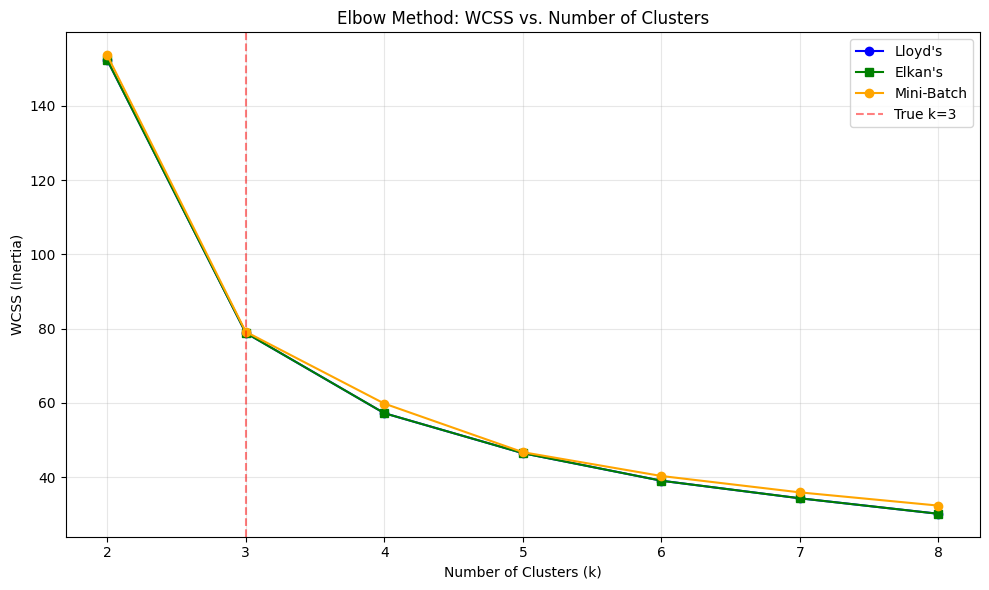


✓ Problem 6: Elbow method complete!

Now answer the analysis questions in the markdown cell above.


In [48]:
def test_problem_6():
    """Test elbow method implementation."""
    print("=" * 60)
    print("Problem 6: Elbow Method")
    print("=" * 60)

    # Load Iris dataset
    iris = load_iris()
    X = iris.data

    # Test compute_wcss_for_k_range
    print("\nTesting WCSS computation for k=2..8...")
    k_range = range(2, 9)
    wcss_lloyd = compute_wcss_for_k_range(fit_lloyd_kmeans, X, k_range)

    # Verify output
    assert len(wcss_lloyd) == len(k_range), \
        f"Expected {len(k_range)} WCSS values, got {len(wcss_lloyd)}"
    assert all(wcss_lloyd > 0), "All WCSS values should be positive!"
    assert all(wcss_lloyd[i] >= wcss_lloyd[i+1] for i in range(len(wcss_lloyd)-1)), \
        "WCSS should decrease (or stay same) as k increases!"

    print("✓ WCSS computation test passed")
    print(f"  WCSS values: {wcss_lloyd}")

    # Create elbow plot
    print("\nCreating elbow plot for all three algorithms...")
    plot_elbow_curves(X, k_range)

    print("\n" + "=" * 60)
    print("✓ Problem 6: Elbow method complete!")
    print("=" * 60)
    print("\nNow answer the analysis questions in the markdown cell above.")

test_problem_6()

## You made it!